In [29]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import openmc
import openmc.stats

RUN_DIR = pathlib.Path('test_source_direction_outputs')
RUN_DIR.mkdir(exist_ok=True)
ALPHA = 0.05

In [30]:
CYLINDER_RADIUS = 5.0
SLAB_THICKNESS = 1.0
A_COEFF = 0.5
N_PERIODS = 2
N_AZIMUTHAL_BINS = 360


def azimuthal_pdf(phi, A=A_COEFF, n=N_PERIODS):
    return (1 + A * np.cos(n * phi)) / (2 * np.pi)


source_phi_values = np.linspace(-np.pi, np.pi, 361)
source_phi_probs = azimuthal_pdf(source_phi_values)
phi_dist = openmc.stats.Tabular(source_phi_values, source_phi_probs, interpolation='linear-linear')
mu_dist = openmc.stats.Uniform(-0.01, 0.01)
angle_dist = openmc.stats.PolarAzimuthal(mu=mu_dist, phi=phi_dist)

In [31]:
openmc.reset_auto_ids()

cylinder = openmc.ZCylinder(r=CYLINDER_RADIUS, boundary_type='vacuum')
z_bottom = openmc.ZPlane(-SLAB_THICKNESS / 2, boundary_type='vacuum')
z_top = openmc.ZPlane(SLAB_THICKNESS / 2, boundary_type='vacuum')
region = -cylinder & +z_bottom & -z_top
vacuum_cell = openmc.Cell(name='vacuum_slab', region=region)
universe = openmc.Universe(cells=[vacuum_cell])
geometry = openmc.Geometry(universe)

In [32]:
source = openmc.IndependentSource(
    space=openmc.stats.Point((0.0, 0.0, 0.0)),
    energy=openmc.stats.Discrete([14.0e6], [1.0]),
    angle=angle_dist,
    particle='neutron',
    strength=1.0
)

In [33]:
azimuthal_bins = np.linspace(-np.pi, np.pi, N_AZIMUTHAL_BINS + 1)
azimuthal_filter = openmc.AzimuthalFilter(azimuthal_bins)
cell_filter = openmc.CellFilter(vacuum_cell)

direction_tally = openmc.Tally(name='angular_distribution')
direction_tally.filters = [cell_filter, azimuthal_filter]
direction_tally.scores = ['flux']
direction_tally.higher_moments = True
tallies = openmc.Tallies([direction_tally])

In [34]:
PARTICLES_PER_BATCH = 100000
N_BATCHES = 100
TOTAL_PARTICLES = PARTICLES_PER_BATCH * N_BATCHES

settings = openmc.Settings()
settings.run_mode = 'fixed source'
settings.particles = PARTICLES_PER_BATCH
settings.batches = N_BATCHES
settings.seed = 456
settings.source = source
settings.output = {'tallies': False}

In [35]:
model = openmc.Model(geometry=geometry, settings=settings, tallies=tallies)
model.export_to_model_xml(path=RUN_DIR)

In [36]:
sp_path = model.run(cwd=RUN_DIR, output=False)

In [37]:
with openmc.StatePoint(sp_path) as sp:
    tally = sp.get_tally(name='angular_distribution')
    tally_mean = tally.mean.flatten()
    tally_std = tally.std_dev.flatten()

phi_profile_mean = tally_mean[:N_AZIMUTHAL_BINS]
phi_profile_std = tally_std[:N_AZIMUTHAL_BINS]
phi_bin_centers = 0.5 * (azimuthal_bins[:-1] + azimuthal_bins[1:])
phi_bin_widths = np.diff(azimuthal_bins)

total_flux = phi_profile_mean.sum()
measured_pdf = phi_profile_mean / (total_flux * phi_bin_widths)
measured_pdf_std = phi_profile_std / (total_flux * phi_bin_widths)

In [38]:
expected_pdf = azimuthal_pdf(phi_bin_centers)
observed_fractions = phi_profile_mean / phi_profile_mean.sum()
expected_fractions = expected_pdf * phi_bin_widths
expected_fractions /= expected_fractions.sum()
eff_sample_size = TOTAL_PARTICLES

In [39]:
z_95 = stats.norm.ppf(0.975)
ci_lower = measured_pdf - z_95 * measured_pdf_std
ci_upper = measured_pdf + z_95 * measured_pdf_std
within_ci = (expected_pdf >= ci_lower) & (expected_pdf <= ci_upper)
ci_coverage = within_ci.mean() * 100

CI_PASS_THRESHOLD = 90.0
ci_test_pass = ci_coverage >= CI_PASS_THRESHOLD

In [40]:
min_expected_fraction = 0.001
valid_bins = expected_fractions > min_expected_fraction
n_valid_bins = valid_bins.sum()

chi2_contributions = np.zeros_like(observed_fractions)
chi2_contributions[valid_bins] = (
    (observed_fractions[valid_bins] - expected_fractions[valid_bins])**2
    / expected_fractions[valid_bins]
)
chi2_stat = eff_sample_size * chi2_contributions[valid_bins].sum()
dof = n_valid_bins - 1
chi2_pvalue = 1 - stats.chi2.cdf(chi2_stat, dof)
chi2_test_pass = chi2_pvalue > ALPHA

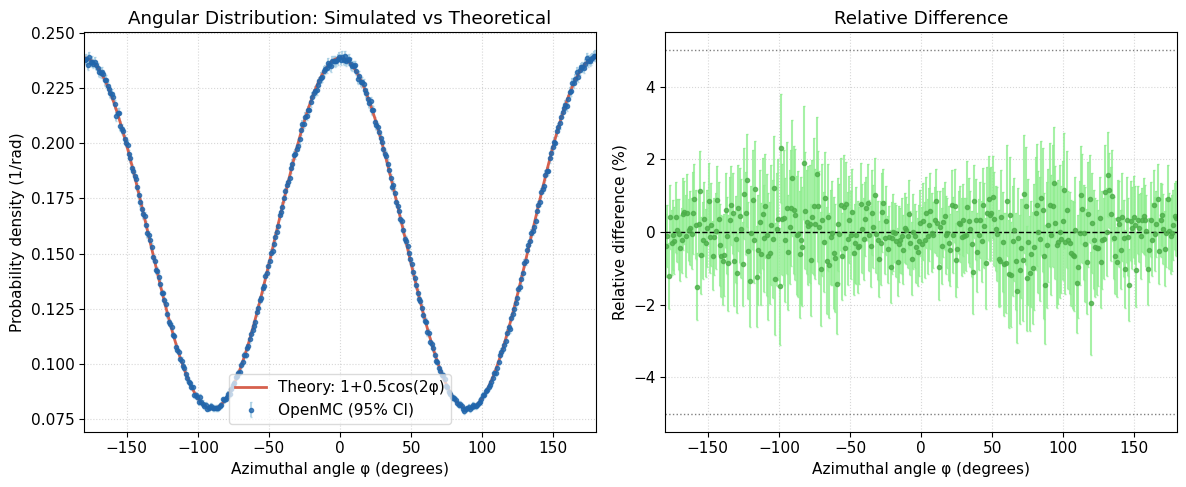

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
phi_centers_deg = np.degrees(phi_bin_centers)

ax = axes[0]
ax.errorbar(phi_centers_deg, measured_pdf,
            yerr=z_95 * measured_pdf_std,
            fmt='o', ms=3, color='#2166ac', ecolor='#a6cee3',
            capsize=1, label='OpenMC (95% CI)', alpha=0.8)
ax.plot(phi_centers_deg, expected_pdf,
        '-', color='#d6604d', lw=2, label=f'Theory: 1+{A_COEFF}cos({N_PERIODS}φ)')
ax.set_xlabel('Azimuthal angle φ (degrees)')
ax.set_ylabel('Probability density (1/rad)')
ax.set_title('Angular Distribution: Simulated vs Theoretical')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)
ax.set_xlim(-180, 180)

ax = axes[1]
rel_diff = (measured_pdf - expected_pdf) / expected_pdf * 100
rel_diff_err = measured_pdf_std / expected_pdf * 100
ax.errorbar(phi_centers_deg, rel_diff,
            yerr=z_95 * rel_diff_err,
            fmt='o', ms=3, color='#4daf4a', ecolor='lightgreen',
            capsize=1, alpha=0.8)
ax.axhline(0, color='k', ls='--', lw=1)
ax.axhline(5, color='gray', ls=':', lw=1)
ax.axhline(-5, color='gray', ls=':', lw=1)
ax.set_xlabel('Azimuthal angle φ (degrees)')
ax.set_ylabel('Relative difference (%)')
ax.set_title('Relative Difference')
ax.grid(True, ls=':', alpha=0.5)
ax.set_xlim(-180, 180)

fig.tight_layout()
plt.savefig('7224_ss_3.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
overall_pass = chi2_test_pass and ci_test_pass

In [43]:
result = 'PASS' if overall_pass else 'FAIL'
with open('results.txt', 'w') as results_file:
    results_file.write(result + '\n')